# Advanced: Reproducing Shupe & Intrieri (2004)

In this notebook, we'll attempt to reproduce a key figure from Shupe & Intrieri (2004) — a seminal paper on the Arctic cloud radiative effect. This involves running hundreds of simulations across a grid of cloud parameters to map the relationship between cloud properties and radiative forcing.

## Overview

- We assume a standard Arctic winter atmosphere from the libRadtran data directory (`/opt/libRadtran-2.0.6/data/atmmod`).
- This notebook executes hundreds of libRadtran simulations, so it may take a while to run. You can speed it up by reducing the number of parameter steps.
- The plot visualizes whether a cloud will cool or warm the surface, and how this depends primarily on the liquid water path (LWP), solar zenith angle, and surface albedo.

In [1]:
import pyradtran
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

solar_config_path = Path('config/arctic_cloud_experiment_solar.yaml')
thermal_config_path = Path('config/arctic_cloud_experiment_thermal.yaml')

## Cloud Radiative Effect Calculation

This is an advanced example showing how to perform sensitivity studies on cloud parameters, calculating the cloud radiative effect (CRE) in a libRadtran setup. We calculate the net irradiance for the solar (300–3000 nm) and thermal (3000–100000 nm) bands, under both cloud-free and cloudy conditions.

| Surface type        | Shortwave albedo α (broadband) | Longwave emissivity ε (8–13 µm) | Notes / typical use |
|---------------------|--------------------------------|----------------------------------|---------------------|
| Open water          | 0.05 – 0.10                    | 0.985 – 0.990                    | Low SW reflectance; near-blackbody in TIR |
| Thin ice (nilas / young ice) | 0.15 – 0.40            | 0.970 – 0.985                    | Strong thickness dependence; key for leads |
| Snow-covered sea ice| 0.75 – 0.90                    | 0.980 – 0.995                    | Very high SW albedo; excellent LW emitter |


In [2]:
albedos_sw = np.arange(0, 1, 0.25)
albedos_lw = np.arange(0, 1, 0.25) * 0  # set to zero (reasonable approximation for high-emissivity surfaces)

# libRadtran handles emissivity as 1 - albedo

In [3]:
# Arctic stratus parameter space (libRadtran units)
cbh   = [0.3]        # km
cth   = [1.0]        # km

lwps = np.array([5, 20, 50, 100, 400])
lwcs = lwps / 700  # convert to kg m^-3 to fill the 700 m layer uniformly
reffs = [15]           

surface_temperatures = np.linspace(273.15, 273.15 - 30, len(albedos_sw))
cbh = [0.3] * len(lwcs)
cth = [1] * len(lwcs)

times = pd.date_range("2024-03-01 12:00", periods=20, freq="7d")
lats = np.arange(80, 60, -1)
print(lats)
lon = [0] * len(times)
altitudes = [0, 1, 10, 100]

ds = xr.Dataset(
    coords={
        "time": times, 
        "latitude": (("time",), lats), 
        "longitude": (("time",), lon),
        "altitude": (("altitude",), altitudes)
    },
    data_vars={
        "lwc": (("lwc",), lwcs),
        "reff": (("reff",), reffs),
        "cth": (("lwc",), cth),
        "cbh": (("lwc",), cbh),
        "surface_temperature": (("albedo",), surface_temperatures),
        "albedo_sw": (("albedo",), albedos_sw),
        "albedo_lw": (("albedo",), albedos_lw),
    }
)

ds_sim_no_cloud_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar.yaml',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_sw',
    save_to_file=True, 
    return_dataset=True,
)

ds_sim_no_cloud_thermal = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_thermal.yaml',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_lw',
    save_to_file=True, 
    return_dataset=True,
)

ds_sim_cloudy_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar.yaml',
    cloud_wc_var='lwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_sw',
    save_to_file=True, 
    return_dataset=True,
)

ds_sim_cloudy_thermal = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_thermal.yaml',
    cloud_wc_var='lwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_lw',
    save_to_file=True, 
    return_dataset=True,
)

[80 79 78 77 76 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61]


Running simulations:   0%|          | 0/400 [00:00<?, ?sim/s]

Running simulations:   0%|          | 1/400 [00:05<35:45,  5.38s/sim]

Running simulations:   0%|          | 1/400 [00:05<35:45,  5.38s/sim, Success=1, Total=400]

Running simulations:   0%|          | 2/400 [00:06<18:13,  2.75s/sim, Success=1, Total=400]

...

Running simulations: 100%|█████████▉| 398/400 [00:26<00:00, 26.41sim/s, Success=398, Total=400]

Running simulations: 100%|█████████▉| 399/400 [00:26<00:00, 22.36sim/s, Success=398, Total=400]

Running simulations: 100%|█████████▉| 399/400 [00:26<00:00, 22.36sim/s, Success=399, Total=400]

Running simulations: 100%|██████████| 400/400 [00:26<00:00, 22.36sim/s, Success=400, Total=400]

Running simulations: 100%|██████████| 400/400 [00:26<00:00, 15.02sim/s, Success=400, Total=400]

## Post-Processing: Cloud Radiative Effect

Compute the cloud radiative effect (CRE) as the difference between cloudy and cloud-free net irradiance, for both the solar and thermal spectral bands.

In [4]:
ds_sim_no_cloud_solar_normed = ds_sim_no_cloud_solar / 1000
ds_sim_cloudy_solar_normed = ds_sim_cloudy_solar / 1000
ds_cre_solar = ds_sim_cloudy_solar_normed - ds_sim_no_cloud_solar_normed
ds_cre_thermal = ds_sim_cloudy_thermal - ds_sim_no_cloud_thermal
ds_cre_total = ds_cre_solar + ds_cre_thermal
ds_cre_total = ds_cre_total.squeeze()

ds_cre_total = ds_cre_total.assign_coords(
    {'albedo' : albedos_sw}
)

In [5]:

ds_cre_total['enet_zero'] = (('lwc', 'albedo', 'time'), np.isclose(ds_cre_total.enet.isel(altitude=0), 0, atol=.5))    

In [6]:
import pandas as pd
import pvlib

def calculate_solar_zenith_angle(time, latitude, longitude):
    solpos = pvlib.solarposition.get_solarposition(times, latitude, longitude)
    return solpos['zenith']
sza = calculate_solar_zenith_angle(ds.time.values, ds.latitude.values, ds.longitude.values)
sza

2024-03-01 12:00:00    87.308757
2024-03-08 12:00:00    83.600046
2024-03-15 12:00:00    79.841690
2024-03-22 12:00:00    76.072131
2024-03-29 12:00:00    72.326330
2024-04-05 12:00:00    68.636291
2024-04-12 12:00:00    65.035708
2024-04-19 12:00:00    61.559141
2024-04-26 12:00:00    58.238263
2024-05-03 12:00:00    55.101745
2024-05-10 12:00:00    52.179414
2024-05-17 12:00:00    49.501237
2024-05-24 12:00:00    47.093743
2024-05-31 12:00:00    44.978874
2024-06-07 12:00:00    43.176652
2024-06-14 12:00:00    41.702779
2024-06-21 12:00:00    40.565954
2024-06-28 12:00:00    39.767156
2024-07-05 12:00:00    39.302199
2024-07-12 12:00:00    39.159366
Freq: 7D, Name: zenith, dtype: float64

In [7]:
ds_cre_total['sza'] = ('time', sza)
ds_cre_sza = ds_cre_total.groupby_bins('sza', [30, 40, 50, 60, 70, 80, 90, 100]).mean()

In [8]:
ds_literature = xr.open_dataset('data/sheba_graph_exact_raster.nc')


/home/josh/micromamba/envs/mamba_josh/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## Visualization: CRE Zero-Crossing Contours

The contour plot below shows the zero-crossing of the net cloud radiative effect as a function of solar zenith angle and surface albedo, for each liquid water path. Lines where CRE = 0 separate the warming and cooling regimes. The rectangle indicates the approximate SHEBA observational domain from Shupe & Intrieri (2004).

Text(0, 0.5, 'Surface albedo ')

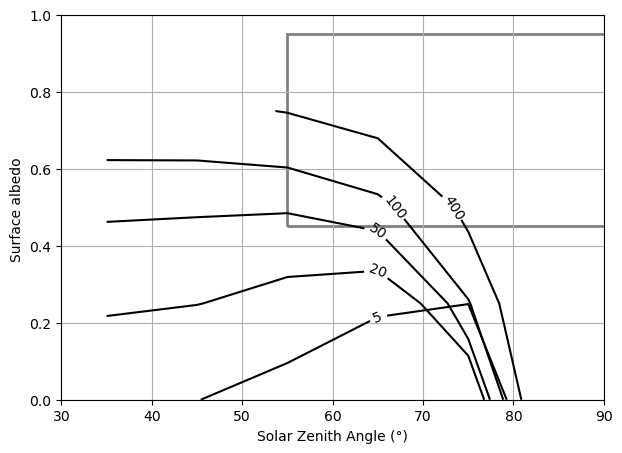

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = plt.cm.inferno(np.linspace(0, 1, len(ds_cre_total.lwc)))

for i, lwc in enumerate(ds_cre_total.lwc.values):
        
    cs = ds_cre_sza.isel(altitude=0).sel(lwc=lwc).enet.plot.contour(x='sza_bins', colors='k', levels=[0])
    # add lwc to complete the label 
    cs.clabel(fmt=f'{lwps[i]}', colors='k')

# show SHEBA region
from matplotlib.patches import Rectangle

ax.add_patch(Rectangle((55, .45), 50, .5, alpha=0.5, edgecolor='k', linewidth=2, fill=False))

ax.set_xlim(30, 90)
ax.set_ylim(0, 1)
ax.set_title('')
ax.grid()
ax.set_xlabel('Solar Zenith Angle (°)')
ax.set_ylabel('Surface albedo ')


## Extension: Ice Cloud Simulations

Below, we repeat the analysis using ice water content (IWC) instead of liquid water content, to explore the radiative effect of ice clouds.

In [10]:
# Ice cloud parameter space (libRadtran units)
cbh   = [0.3]        # km
cth   = [1.0]        # km

lwps = np.array([10, 15, 20, 30, 50, 100, 200, 400, 800])
iwcs = lwps / 700
reffs = [15]          # µm

surface_temperatures = np.linspace(273.15, 273.15 - 30, len(albedos_sw))
cbh = [0.3] * len(iwcs)
cth = [1] * len(iwcs)

times = pd.date_range("2024-03-01 12:00", periods=20, freq="7d")
lats = np.arange(80, 60, -1)
print(lats)
lon = [0] * len(times)
altitudes = [0, 1, 10, 100]

ds = xr.Dataset(
    coords={
        "time": times, 
        "latitude": (("time",), lats), 
        "longitude": (("time",), lon),
        "altitude": (("altitude",), altitudes)
    },
    data_vars={
        "iwc": (("iwc",), lwcs),
        "reff": (("reff",), reffs),
        "cth": (("iwc",), cth),
        "cbh": (("iwc",), cbh),
        "surface_temperature": (("albedo",), surface_temperatures),
        "albedo_sw": (("albedo",), albedos_sw),
        "albedo_lw": (("albedo",), albedos_lw),
    }
)

ds_sim_cloudy_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar.yaml',
    cloud_ic_var='iwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    surface_temperature_var='surface_temperature',
    albedo_var='albedo_sw',
    save_to_file=True, 
    return_dataset=True,
)

[80 79 78 77 76 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61]


ValueError: conflicting sizes for dimension 'iwc': length 9 on 'cth' and length 5 on {'iwc': 'iwc', 'reff': 'reff'}

## Results: Cloud Effect on Surface Net Radiation

Here we show the effect of the cloud on the surface net radiation, depending on the surface type.